## **Исследование факторов, связанных с результатами SAT в старших школах Нью-Йорка**

В рамках данного проекта проводится исследование данных о старших школах Нью-Йорка с целью выявления факторов, связанных с результатами экзамена SAT (Scholastic Assessment Test). В ходе работы выполняется комплексная подготовка данных, включающая объединение информации из разных источников, обработку пропущенных значений, устранение несоответствий и приведение данных к единому структурированному формату. 

Учитывая разнообразие населения Нью-Йорка, особое внимание уделяется анализу взаимосвязей между демографическими характеристиками учащихся (например, расовой принадлежностью, уровнем дохода семьи, полом) и результатами SAT. Такое сопоставление позволит оценить, существуют ли значимые различия в успеваемости между определёнными группами выпускников.

In [1]:
#Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Используются следующие наборы данных о старших школах Нью-Йорка:

- [AP test results](https://data.cityofnewyork.us/Education/2010-AP-College-Board-School-Level-Results/itfs-ms3e/about_data) – результаты экзаменов Advanced Placement (AP), файл ap_2010.csv
- [Class size](https://data.cityofnewyork.us/Education/2010-2011-Class-Size-School-level-detail/urz7-pzb3) – информация о размере классов, файл class_size.csv
- [Demographics](https://data.cityofnewyork.us/Education/2006-2012-School-Demographics-and-Accountability-S/ihfw-zy9j/about_data) – демографические данные учащихся, файл demographics.csv
- [Graduation outcomes](https://data.cityofnewyork.us/Education/Graduation-Outcomes-Classes-Of-2005-2010-School-Le/vh2h-md7a) – данные о выпускниках и результатах обучения, файл graduation.csv
- [A directory of high schools](https://data.cityofnewyork.us/Education/2014-2015-DOE-High-School-Directory/n3p6-zve2/about_data) – справочная информация о старших школах, файл hs_directory.csv
- [SAT scores by school](https://data.cityofnewyork.us/Education/2012-SAT-Results/f9bf-2cp4/about_data) – результаты SAT для каждой школы, файл sat_results.csv
- [School survey (all schools)](https://data.cityofnewyork.us/Education/2011-NYC-School-Survey/mnz3-dyi8/about_data) – результаты опросов учащихся, родителей и преподавателей всех школ, файл survey_all.txt
- [School survey (District 75 schools)](https://www.schools.nyc.gov/learning/special-education/school-settings/district-75) - результаты опросов школ 75-го округа Нью-Йорка, файл survey_d75.txt

На данном этапе выполняется загрузка CSV-файлов из директории `schools/`. Каждый файл считывается в датафрейм и сохраняется в словарь `data`. Это позволяет структурировать данные и подготовить их к дальнейшей очистке:

In [2]:
data_files = [
    "ap_2010.csv",
    "class_size.csv",
    "demographics.csv",
    "graduation.csv",
    "hs_directory.csv",
    "sat_results.csv"
]
data = {}

for f in data_files:
    key_name = f.replace(".csv", "")
    df = pd.read_csv(f"schools/{f}")
    data[key_name] = df

Результаты опросов загружаются из текстовых файлов `survey_all.txt` и `survey_d75.txt` с использованием табуляции в качестве разделителя:

In [3]:
all_survey = pd.read_csv("schools/survey_all.txt", delimiter="\t", encoding='windows-1252')
d75_survey = pd.read_csv("schools/survey_d75.txt", delimiter="\t", encoding='windows-1252')

#Объединим их в общий датафрейм survey
survey = pd.concat([all_survey, d75_survey], axis=0)

survey = survey.copy()
survey.rename({'dbn':'DBN'}, axis = 1, inplace = True)
survey.head(2)

,DBN,bn,schoolname,d75,studentssurveyed,highschool,schooltype,rr_s,rr_t,rr_p,...,s_q14_2,s_q14_3,s_q14_4,s_q14_5,s_q14_6,s_q14_7,s_q14_8,s_q14_9,s_q14_10,s_q14_11
0,01M015,M015,P.S. 015 Roberto Clemente,0,No,0.0,Elementary School,NaN,88,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01M019,M019,P.S. 019 Asher Levy,0,No,0.0,Elementary School,NaN,100,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Дальнейший анализ будет опираться только на наиболее значимые показатели, выявленные в школьных опросах, а именно:
- сведения об активности участия в анкетировании;
- оценки образовательной среды, полученные от учащихся, преподавателей и родителей ([см. источник](https://data.cityofnewyork.us/Education/2011-NYC-School-Survey/mnz3-dyi8/about_data))

| Столбец | Описание |
|---|---|
| **DBN** | Уникальный идентификатор школы (District Borough Number)|
| **rr_s** | Процент ответов учащихся в школьном опросе (Student Response Rate) |
| **rr_t** | Процент ответов преподавателей в школьном опросе (Teacher Response Rate)|
| **rr_p** | Процент ответов родителей в школьном опросе (Parent Response Rate) |
| **N_s** | Количество учащихся, принявших участие в опросе |
| **N_t** | Количество преподавателей, принявших участие в опросе |
| **N_p** | Количество родителей, принявших участие в опросе |
| **saf_p_11** | Оценка безопасности и уважительного отношения по ответам родителей |
| **com_p_11** | Оценка качества коммуникации по ответам родителей |
| **eng_p_11** | Оценка вовлечённости учащихся по ответам родителей |
| **aca_p_11** | Оценка академических ожиданий по ответам родителей |
| **saf_t_11** | Оценка безопасности и уважительного отношения по ответам преподавателей |
| **com_t_11** | Оценка качества коммуникации по ответам преподавателей |
| **eng_t_11** | Оценка вовлечённости учащихся по ответам преподавателей |
| **aca_t_11** | Оценка академических ожиданий по ответам преподавателей |
| **saf_s_11** | Оценка безопасности и уважительного отношения по ответам учащихся |
| **com_s_11** | Оценка качества коммуникации по ответам учащихся |
| **eng_s_11** | Оценка вовлечённости учащихся по ответам учащихся |
| **aca_s_11** | Оценка академических ожиданий по ответам учащихся |
| **saf_tot_11** | Общая оценка безопасности и уважительного отношения в школе |
| **com_tot_11** | Общая оценка качества коммуникации в школе |
| **eng_tot_11** | Общая оценка вовлечённости учащихся |
| **aca_tot_11** | Общая оценка академических ожиданий в школе |

In [4]:
#Отбираем необходимые столбцы
survey_fields = [
    "DBN", 
    "rr_s", 
    "rr_t", 
    "rr_p", 
    "N_s", 
    "N_t", 
    "N_p", 
    "saf_p_11", 
    "com_p_11", 
    "eng_p_11", 
    "aca_p_11", 
    "saf_t_11", 
    "com_t_11", 
    "eng_t_11", 
    "aca_t_11", 
    "saf_s_11", 
    "com_s_11", 
    "eng_s_11", 
    "aca_s_11", 
    "saf_tot_11", 
    "com_tot_11", 
    "eng_tot_11", 
    "aca_tot_11",
]
survey = survey[survey_fields]

#После фильтрации датафрейм сохраняется в общий словарь data
data["survey"] = survey

---

Перед объединением датафреймов с помощью `merge()` требуется привести идентификатор школы (`DBN`) к единому формату во всех наборах данных. В некоторых датафреймах данный столбец имеет название `dbn`, а в `class_size` (содержащем данные о размере классов) идентификатор школы и вовсе отсутствует в явном виде, однако его можно сформировать посредством объединения значений в столбцах `CSD` и `SCHOOL CODE`. 

При этом значения в столбце `CSD` (код района) следует привести к двухзначному формату с добавлением ведущего нуля при необходимости:

In [5]:
data["class_size"].head(2)

,CSD,BOROUGH,SCHOOL CODE,SCHOOL NAME,GRADE,PROGRAM TYPE,CORE SUBJECT (MS CORE and 9-12 ONLY),CORE COURSE (MS CORE and 9-12 ONLY),SERVICE CATEGORY(K-9* ONLY),NUMBER OF STUDENTS / SEATS FILLED,NUMBER OF SECTIONS,AVERAGE CLASS SIZE,SIZE OF SMALLEST CLASS,SIZE OF LARGEST CLASS,DATA SOURCE,SCHOOLWIDE PUPIL-TEACHER RATIO
0,1,M,M015,P.S. 015 Roberto Clemente,0K,GEN ED,-,-,-,19.0,1.0,19.0,19.0,19.0,ATS,NaN
1,1,M,M015,P.S. 015 Roberto Clemente,0K,CTT,-,-,-,21.0,1.0,21.0,21.0,21.0,ATS,NaN


In [6]:
#Переименование столбца датафрейма hs_directory
data["hs_directory"].rename({'dbn':'DBN'}, axis = 1, inplace = True)

#В стандартизированном виде идентификатор школы DBN должен содержать ведущий 0, если его число изначально не представлено двумя цифрами:
data["class_size"]["padded_csd"] = data["class_size"]["CSD"].map(lambda c: str(c).zfill(2))
#Объединим код школы с преобразованным кодом района (CSD)
data["class_size"]["DBN"] = data["class_size"]["padded_csd"] + data["class_size"]["SCHOOL CODE"]
data["class_size"].head()

,CSD,BOROUGH,SCHOOL CODE,SCHOOL NAME,GRADE,PROGRAM TYPE,CORE SUBJECT (MS CORE and 9-12 ONLY),CORE COURSE (MS CORE and 9-12 ONLY),SERVICE CATEGORY(K-9* ONLY),NUMBER OF STUDENTS / SEATS FILLED,NUMBER OF SECTIONS,AVERAGE CLASS SIZE,SIZE OF SMALLEST CLASS,SIZE OF LARGEST CLASS,DATA SOURCE,SCHOOLWIDE PUPIL-TEACHER RATIO,padded_csd,DBN
0,1,M,M015,P.S. 015 Roberto Clemente,0K,GEN ED,-,-,-,19.0,1.0,19.0,19.0,19.0,ATS,NaN,01,01M015
1,1,M,M015,P.S. 015 Roberto Clemente,0K,CTT,-,-,-,21.0,1.0,21.0,21.0,21.0,ATS,NaN,01,01M015
2,1,M,M015,P.S. 015 Roberto Clemente,01,GEN ED,-,-,-,17.0,1.0,17.0,17.0,17.0,ATS,NaN,01,01M015
3,1,M,M015,P.S. 015 Roberto Clemente,01,CTT,-,-,-,17.0,1.0,17.0,17.0,17.0,ATS,NaN,01,01M015
4,1,M,M015,P.S. 015 Roberto Clemente,02,GEN ED,-,-,-,15.0,1.0,15.0,15.0,15.0,ATS,NaN,01,01M015


Как можно заметить, в датафрейме `class_size` одному идентификатору школы (`DBN`) соответствует несколько записей. Вероятно, это связано с тем, что данные представлены для разных классов и образовательных программ, указанных в столбцах `GRADE` и `PROGRAM TYPE`. Рассмотрим их подробнее, чтобы понять, какую информацию они содержат и какие записи следует оставить:

In [7]:
class_size = data["class_size"]
class_size["GRADE "].value_counts()

GRADE 
09-12      10644
MS Core     4762
0K-09       1384
0K          1237
01          1185
02          1167
03          1143
04          1140
05          1086
06           846
07           778
08           735
09            20
Name: count, dtype: int64

In [8]:
class_size["PROGRAM TYPE"].value_counts()

PROGRAM TYPE
GEN ED     14545
CTT         7460
SPEC ED     3653
G&T          469
Name: count, dtype: int64

Поскольку наш анализ посвящен старшим школам, целесообразно оставить только те записи, которые относятся к учащимся 9-12 классов (`GRADE` = "09-12") и программе общего образования (`PROGRAM TYPE` = "GEN ED"). Это позволит получить по одной релевантной записи для каждой школы и исключить данные, относящиеся к другим уровням обучения и специализированным программам:

In [9]:
class_size = class_size[((class_size['GRADE '] == '09-12') & (class_size['PROGRAM TYPE'] == 'GEN ED'))]
class_size

,CSD,BOROUGH,SCHOOL CODE,SCHOOL NAME,GRADE,PROGRAM TYPE,CORE SUBJECT (MS CORE and 9-12 ONLY),CORE COURSE (MS CORE and 9-12 ONLY),SERVICE CATEGORY(K-9* ONLY),NUMBER OF STUDENTS / SEATS FILLED,NUMBER OF SECTIONS,AVERAGE CLASS SIZE,SIZE OF SMALLEST CLASS,SIZE OF LARGEST CLASS,DATA SOURCE,SCHOOLWIDE PUPIL-TEACHER RATIO,padded_csd,DBN
225,1,M,M292,Henry Street School for International Studies,09-12,GEN ED,ENGLISH,English 9,-,63.0,3.0,21.0,19.0,25.0,STARS,NaN,01,01M292
226,1,M,M292,Henry Street School for International Studies,09-12,GEN ED,ENGLISH,English 10,-,79.0,3.0,26.3,24.0,31.0,STARS,NaN,01,01M292
227,1,M,M292,Henry Street School for International Studies,09-12,GEN ED,ENGLISH,English 11,-,38.0,2.0,19.0,16.0,22.0,STARS,NaN,01,01M292
228,1,M,M292,Henry Street School for International Studies,09-12,GEN ED,ENGLISH,English 12,-,69.0,3.0,23.0,13.0,30.0,STARS,NaN,01,01M292
229,1,M,M292,Henry Street School for International Studies,09-12,GEN ED,MATH,Integrated Algebra,-,53.0,3.0,17.7,16.0,21.0,STARS,NaN,01,01M292
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27604,32,K,K564,Bushwick Community High School,09-12,GEN ED,SCIENCE,Physics,-,49.0,2.0,24.5,22.0,27.0,STARS,NaN,32,32K564
27605,32,K,K564,Bushwick Community High School,09-12,GEN ED,SOCIAL STUDIES,Global History & Geography,-,237.0,10.0,23.7,15.0,31.0,STARS,NaN,32,32K564
27606,32,K,K564,Bushwick Community High School,09-12,GEN ED,SOCIAL STUDIES,US History & Government,-,256.0,10.0,25.6,15.0,35.0,STARS,NaN,32,32K564
27607,32,K,K564,Bushwick Community High School,09-12,GEN ED,SOCIAL STUDIES,Economics,-,65.0,2.0,32.5,32.0,33.0,STARS,NaN,32,32K564


После фильтрации данных `DBN` по-прежнему не обеспечивает уникальность записей: одна и та же школа представлена несколькими строками – отдельно для каждого предмета (`CORE SUBJECT (MS CORE and 9-12 ONLY)`) и курса (`CORE COURSE (MS CORE and 9-12 ONLY)`).

In [10]:
print(class_size['CORE SUBJECT (MS CORE and 9-12 ONLY)'].unique())
print(class_size['CORE COURSE (MS CORE and 9-12 ONLY)'].unique())

['ENGLISH' 'MATH' 'SCIENCE' 'SOCIAL STUDIES']
['English 9' 'English 10' 'English 11' 'English 12' 'Integrated Algebra'
 'Geometry' 'Other Math' 'Earth Science' 'Living Environment' 'Chemistry'
 'Physics' 'Other Science' 'Global History & Geography'
 'US History & Government' 'MS English Core' 'Other English'
 'Trigonometry' 'Participation in Government' 'Math A' 'Economics'
 'Other Social Studies' 'Math B']


Для решения этой проблемы сгруппируем данные по столбцу `DBN`. Для числовых столбцов в качестве агрегирующей функции используем среднее значение (`mean`). Cохраним полученный агрегированный датафрейм в словаре `data`:

In [11]:
class_size = class_size.groupby('DBN').agg('mean', numeric_only=True).reset_index()

data['class_size'] = class_size
data['class_size'].tail(3)

,DBN,CSD,NUMBER OF STUDENTS / SEATS FILLED,NUMBER OF SECTIONS,AVERAGE CLASS SIZE,SIZE OF SMALLEST CLASS,SIZE OF LARGEST CLASS,SCHOOLWIDE PUPIL-TEACHER RATIO
580,32K554,32.0,66.937500,3.812500,17.793750,14.750000,21.625000,NaN
581,32K556,32.0,132.333333,5.400000,25.060000,18.333333,30.000000,NaN
582,32K564,32.0,136.142857,5.428571,24.964286,20.071429,28.571429,NaN


---

В датафрейме `demographics` наблюдается аналогичная ситуация: одному идентификатору школы (`DBN`) соответствует несколько записей:

In [12]:
demographics = data['demographics']
demographics.head()

,DBN,Name,schoolyear,fl_percent,frl_percent,total_enrollment,prek,k,grade1,grade2,...,black_num,black_per,hispanic_num,hispanic_per,white_num,white_per,male_num,male_per,female_num,female_per
0,01M015,P.S. 015 ROBERTO CLEMENTE,20052006,89.4,NaN,281,15,36,40,33,...,74,26.3,189,67.3,5,1.8,158.0,56.2,123.0,43.8
1,01M015,P.S. 015 ROBERTO CLEMENTE,20062007,89.4,NaN,243,15,29,39,38,...,68,28.0,153,63.0,4,1.6,140.0,57.6,103.0,42.4
2,01M015,P.S. 015 ROBERTO CLEMENTE,20072008,89.4,NaN,261,18,43,39,36,...,77,29.5,157,60.2,7,2.7,143.0,54.8,118.0,45.2
3,01M015,P.S. 015 ROBERTO CLEMENTE,20082009,89.4,NaN,252,17,37,44,32,...,75,29.8,149,59.1,7,2.8,149.0,59.1,103.0,40.9
4,01M015,P.S. 015 ROBERTO CLEMENTE,20092010,,96.5,208,16,40,28,32,...,67,32.2,118,56.7,6,2.9,124.0,59.6,84.0,40.4


Различия в значениях столбца `schoolyear` свидетельствуют о том, что данные представлены за несколько учебных лет. Рассмотрим их распределение, чтобы определить, какой учебный год следует выбрать для дальнейшего анализа:

In [13]:
demographics["schoolyear"].value_counts()

schoolyear
20112012    1509
20102011    1498
20092010    1475
20082009    1441
20072008    1410
20062007    1386
20052006    1356
Name: count, dtype: int64

Оставим наиболее актуальные данные – записи за последний доступный учебный год (`schoolyear` = 20112012):

In [14]:
demographics = demographics[demographics["schoolyear"] == 20112012]
data["demographics"] = demographics
data["demographics"].head(2)

,DBN,Name,schoolyear,fl_percent,frl_percent,total_enrollment,prek,k,grade1,grade2,...,black_num,black_per,hispanic_num,hispanic_per,white_num,white_per,male_num,male_per,female_num,female_per
6,01M015,P.S. 015 ROBERTO CLEMENTE,20112012,NaN,89.4,189,13,31,35,28,...,63,33.3,109,57.7,4,2.1,97.0,51.3,92.0,48.7
13,01M019,P.S. 019 ASHER LEVY,20112012,NaN,61.5,328,32,46,52,54,...,81,24.7,158,48.2,28,8.5,147.0,44.8,181.0,55.2


---

В датафрейме `graduation` также содержится несколько записей для одной школы. По всей видимости, это связано с тем, что данные представлены для разных когорт выпускников (`Cohort`) и демографических групп (`Demographic`):

In [15]:
graduation = data['graduation']
graduation.head()

,Demographic,DBN,School Name,Cohort,Total Cohort,Total Grads - n,Total Grads - % of cohort,Total Regents - n,Total Regents - % of cohort,Total Regents - % of grads,...,Regents w/o Advanced - n,Regents w/o Advanced - % of cohort,Regents w/o Advanced - % of grads,Local - n,Local - % of cohort,Local - % of grads,Still Enrolled - n,Still Enrolled - % of cohort,Dropped Out - n,Dropped Out - % of cohort
0,Total Cohort,01M292,HENRY STREET SCHOOL FOR INTERNATIONAL,2003,5,s,s,s,s,s,...,s,s,s,s,s,s,s,s,s,s
1,Total Cohort,01M292,HENRY STREET SCHOOL FOR INTERNATIONAL,2004,55,37,67.3%,17,30.9%,45.9%,...,17,30.9%,45.9%,20,36.4%,54.1%,15,27.3%,3,5.5%
2,Total Cohort,01M292,HENRY STREET SCHOOL FOR INTERNATIONAL,2005,64,43,67.2%,27,42.2%,62.8%,...,27,42.2%,62.8%,16,25%,37.200000000000003%,9,14.1%,9,14.1%
3,Total Cohort,01M292,HENRY STREET SCHOOL FOR INTERNATIONAL,2006,78,43,55.1%,36,46.2%,83.7%,...,36,46.2%,83.7%,7,9%,16.3%,16,20.5%,11,14.1%
4,Total Cohort,01M292,HENRY STREET SCHOOL FOR INTERNATIONAL,2006 Aug,78,44,56.4%,37,47.4%,84.1%,...,37,47.4%,84.1%,7,9%,15.9%,15,19.2%,11,14.1%


In [16]:
graduation["Cohort"].value_counts()

Cohort
2006 Aug    4131
2006        4130
2005        3963
2004        3708
2003        3432
2002        3095
2001        2637
Name: count, dtype: int64

In [17]:
graduation["Demographic"].value_counts()

Demographic
Total Cohort                   2493
Special Education Students     2471
English Proficient Students    2471
General Education Students     2471
Male                           2412
Black                          2403
Female                         2397
Hispanic                       2385
English Language Learners      2036
Asian                          1780
White                          1777
Name: count, dtype: int64

Наше предположение подтвердилось. Оставим только те строки, для которых `Cohort` равен "2006", а `Demographic` – "Total Cohort", то есть данные по общей когорте выпускников 2006 года без разделения по демографическим признакам:

In [18]:
graduation = graduation[((graduation['Cohort'] == '2006') & (graduation['Demographic'] == 'Total Cohort'))]
data['graduation'] = graduation
data['graduation'].head(3)

,Demographic,DBN,School Name,Cohort,Total Cohort,Total Grads - n,Total Grads - % of cohort,Total Regents - n,Total Regents - % of cohort,Total Regents - % of grads,...,Regents w/o Advanced - n,Regents w/o Advanced - % of cohort,Regents w/o Advanced - % of grads,Local - n,Local - % of cohort,Local - % of grads,Still Enrolled - n,Still Enrolled - % of cohort,Dropped Out - n,Dropped Out - % of cohort
3,Total Cohort,01M292,HENRY STREET SCHOOL FOR INTERNATIONAL,2006,78,43,55.1%,36,46.2%,83.7%,...,36,46.2%,83.7%,7,9%,16.3%,16,20.5%,11,14.1%
10,Total Cohort,01M448,UNIVERSITY NEIGHBORHOOD HIGH SCHOOL,2006,124,53,42.7%,42,33.9%,79.2%,...,34,27.4%,64.2%,11,8.9%,20.8%,46,37.1%,20,16.100000000000001%
17,Total Cohort,01M450,EAST SIDE COMMUNITY SCHOOL,2006,90,70,77.8%,67,74.400000000000006%,95.7%,...,67,74.400000000000006%,95.7%,3,3.3%,4.3%,15,16.7%,5,5.6%


---

Следующим шагом приведём столбцы с результатами SAT в датафрейме `sat_results` к числовому типу:

In [19]:
cols = ['SAT Math Avg. Score', 'SAT Critical Reading Avg. Score', 'SAT Writing Avg. Score']
data['sat_results'][cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478 entries, 0 to 477
Data columns (total 3 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   SAT Math Avg. Score              478 non-null    object
 1   SAT Critical Reading Avg. Score  478 non-null    object
 2   SAT Writing Avg. Score           478 non-null    object
dtypes: object(3)
memory usage: 11.3+ KB


In [20]:
for c in cols:
    data["sat_results"][c] = pd.to_numeric(data["sat_results"][c], errors="coerce")

На их основе создадим новый столбец `sat_score`, содержащий сумму баллов по всем трём экзаменам (максимальное значение – 2400):

In [21]:
data['sat_results']['sat_score'] = data['sat_results'][cols].sum(axis = 1, skipna=False) #Если в каком либо экзамене пропущенное значение, то результат суммы будет тоже NaN
data['sat_results']

,DBN,SCHOOL NAME,Num of SAT Test Takers,SAT Critical Reading Avg. Score,SAT Math Avg. Score,SAT Writing Avg. Score,sat_score
0,01M292,HENRY STREET SCHOOL FOR INTERNATIONAL STUDIES,29,355.0,404.0,363.0,1122.0
1,01M448,UNIVERSITY NEIGHBORHOOD HIGH SCHOOL,91,383.0,423.0,366.0,1172.0
2,01M450,EAST SIDE COMMUNITY SCHOOL,70,377.0,402.0,370.0,1149.0
3,01M458,FORSYTH SATELLITE ACADEMY,7,414.0,401.0,359.0,1174.0
4,01M509,MARTA VALLE HIGH SCHOOL,44,390.0,433.0,384.0,1207.0
...,...,...,...,...,...,...,...
473,75X012,P.S. X012 LEWIS AND CLARK SCHOOL,s,NaN,NaN,NaN,NaN
474,75X754,J. M. RAPPORT SCHOOL CAREER DEVELOPMENT,s,NaN,NaN,NaN,NaN
475,79M645,SCHOOL FOR COOPERATIVE TECHNICAL EDUCATION,s,NaN,NaN,NaN,NaN
476,79Q950,GED PLUS s CITYWIDE,8,496.0,400.0,426.0,1322.0


---

Чтобы точно определить местоположение интересующей нас школы, извлечём её координаты из столбца `Location 1` датафрейма `hs_directory`:

In [22]:
print(data["hs_directory"]["Location 1"].unique()[:5])

['883 Classon Avenue\nBrooklyn, NY 11225\n(40.67029890700047, -73.96164787599963)'
 '1110 Boston Road\nBronx, NY 10456\n(40.8276026690005, -73.90447525699966)'
 '1501 Jerome Avenue\nBronx, NY 10452\n(40.842414068000494, -73.91616158599965)'
 '411 Pearl Street\nNew York, NY 10038\n(40.71067947100045, -74.00080702099967)'
 '160-20 Goethals Avenue\nJamaica, NY 11432\n(40.718810094000446, -73.80650045499965)']


С помощью регулярного выражения выделим значения широты (`lat`) и долготы (`lon`):

In [23]:
#Регулярное выражение для поиска координат школы в строке и извлечения долготы (lat) и широты (lon)
pattern = r"\((?P<lat>.+), (?P<lon>.+)\)"
coords = data["hs_directory"]["Location 1"].str.extract(pattern)
coords.head(5)

,lat,lon
0,40.67029890700047,-73.96164787599963
1,40.8276026690005,-73.90447525699966
2,40.842414068000494,-73.91616158599965
3,40.71067947100045,-74.00080702099967
4,40.718810094000446,-73.80650045499965


Как мы видим, координаты были успешно извлечены в виде отдельных именованных столбцов. Присвоим их новым столбцам в датафрейме `hs_directory`:

In [24]:
cols_coord = ['lat', 'lon']
data["hs_directory"][cols_coord] = coords[cols_coord]

#Изменим тип данных извлеченных координат со строкового на числовой
for c in cols_coord:
    data["hs_directory"][c] = pd.to_numeric(data["hs_directory"][c], errors="coerce")

print(data["hs_directory"][cols_coord].dtypes)
data["hs_directory"].head(2)

lat    float64
lon    float64
dtype: object


,DBN,school_name,boro,building_code,phone_number,fax_number,grade_span_min,grade_span_max,expgrade_span_min,expgrade_span_max,...,priority04,priority05,priority06,priority07,priority08,priority09,priority10,Location 1,lat,lon
0,17K548,Brooklyn School for Music & Theatre,Brooklyn,K440,718-230-6250,718-230-6262,9,12,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"883 Classon Avenue\nBrooklyn, NY 11225\n(40.67...",40.670299,-73.961648
1,09X543,High School for Violin and Dance,Bronx,X400,718-842-0687,718-589-9849,9,12,NaN,NaN,...,Then to New York City residents,NaN,NaN,NaN,NaN,NaN,NaN,"1110 Boston Road\nBronx, NY 10456\n(40.8276026...",40.827603,-73.904475


---

Последним шагом перед объединением данных приведём столбцы с результатами AP-тестов в датафрейме `ap_2010` к числовому типу:

In [25]:
cols = ['AP Test Takers ', 'Total Exams Taken', 'Number of Exams with scores 3 4 or 5']

for col in cols:
    data['ap_2010'][col] = pd.to_numeric(data['ap_2010'][col], errors = 'coerce')

В качестве основного датафрейма для дальнейшего объединения используем `sat_results`, к которому последовательно добавим данные из остальных наборов по идентификатору школы `DBN`:

In [26]:
combined = data["sat_results"]
print(combined.shape)

(478, 7)


Поскольку целью анализа является изучение факторов, связанных с результатами SAT, важно сохранить как можно больше школ из исходного датафрейма `sat_results`. Поэтому при объединении с датафреймами `ap_2010` и `graduation` используется левое соединение (left):

In [27]:
combined = pd.merge(left = combined, right = data['ap_2010'], on = 'DBN', how = 'left')
combined = pd.merge(left = combined, right = data['graduation'], on = 'DBN', how = 'left')

Для датафреймов `class_size`, `demographics`, `survey` и `hs_directory` применяется внутреннее соединение (inner), поскольку они содержат важные для анализа характеристики школ и имеют минимальное количество пропущенных значений по идентификатору `DBN`. Такой подход позволит сформировать единый согласованный датасет, включающий только школы, для которых доступны все необходимые данные:

In [28]:
to_merge_inner = ['class_size', 'demographics', 'survey', 'hs_directory']
for m in to_merge_inner:
    combined = pd.merge(left = combined, right = data[m], on = 'DBN', how = 'inner')

После объединения данных заполним пропуски в числовых столбцах их средними значениями:

In [29]:
#Заполняем пропуски в числовых столбцах средним значением по данному столбцу
combined = combined.fillna(combined.mean(numeric_only=True))
#Используем метод для приведения столбцов датафрейма к числовым типам, если это возможно, с заполнением отсутствующих данных 0
combined = combined.infer_objects(copy=False).fillna(0)
combined = combined.copy()
print(combined.shape)

(363, 158)


Теперь у нас есть очищенный набор данных, подготовленный для дальнейшего изучения и выявления закономерностей.

---

В рамках нашего исследования особый интерес представляют взаимосвязи между различными показателями школ и результатами экзамена SAT. Для оценки этих зависимостей воспользуемся функцией `corr()`:

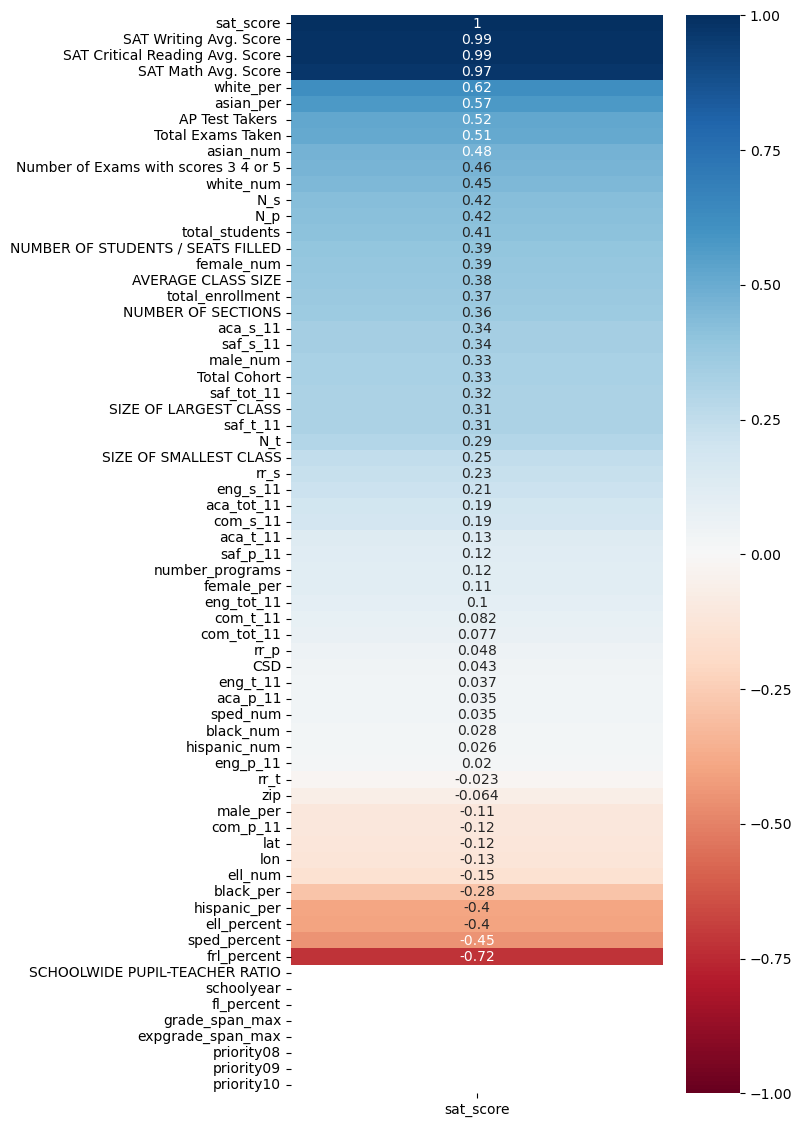

In [30]:
correlations = combined.corr(numeric_only=True)[["sat_score"]].sort_values("sat_score", ascending = False)

plt.figure(figsize = (6,14))
ax = sns.heatmap(correlations, vmin=-1, vmax = 1, cmap = 'RdBu', annot = True)
plt.show()

Неудивительно, что средние баллы по отдельным разделам SAT (`Critical Reading`, `Math`, `Writing`), а также общий показатель `sat_score` имеют сильную положительную корреляцию между собой.

Также можно выделить несколько интересных наблюдений:

- Общее количество учащихся (`total_enrollment`) имеет умеренную положительную корреляцию с результатами SAT. Это может показаться неожиданным, поскольку предполагалось, что в небольших школах ученики смогут получать больше индивидуального внимания и, как следствие, показывать более высокие результаты на экзаменах. Однако данные показывают обратную тенденцию: школы с большим количеством учащихся в среднем демонстрируют более высокие баллы SAT.

- Процент учащихся, имеющих право на бесплатное или льготное питание (`frl_percent`), имеет сильную отрицательную корреляцию с результатами SAT. Это означает, что школы с большей долей учащихся из семей с низким уровнем дохода в среднем показывают более низкие результаты SAT. Такая зависимость представляет особый интерес, поскольку можно было бы ожидать, что учащиеся, стремящиеся улучшить своё социально-экономическое положение, будут демонстрировать высокую мотивацию к получению образования. Однако данная связь может быть обусловлена не столько самим стремлением учащихся, сколько различиями в доступе к образовательным ресурсам, подготовительным материалам и поддержке со стороны взрослых. Учащиеся могут иметь желание добиться успеха, но при этом не всегда обладать необходимыми знаниями о том, как эффективно готовиться к экзаменам. В такой ситуации важную роль играют школы и учителя, предоставляя дополнительные возможности для подготовки и помогая ученикам реализовать свой потенциал. Поэтому полученную зависимость следует рассматривать как показатель потенциального неравенства образовательных условий, требующий дополнительного изучения.

Для более детального изучения связи между количеством учащихся и результатами SAT построим диаграмму рассеяния. Каждая точка на диаграмме будет представлять отдельную среднюю школу, что позволит визуально оценить наличие возможных закономерностей между размером школы и результатами экзамена:

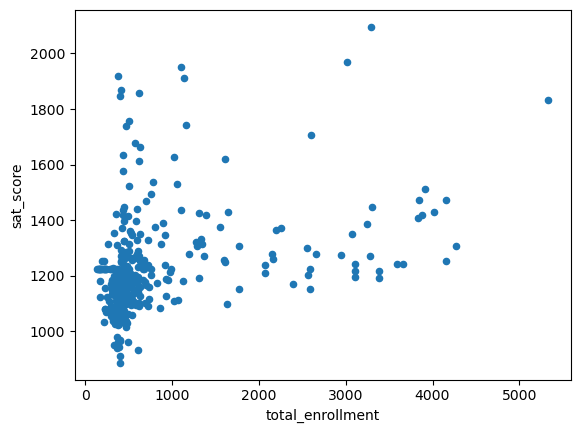

In [31]:
combined.plot(kind = 'scatter', x = 'total_enrollment', y = 'sat_score')
plt.show()

График показывает отсутствие выраженной линейной зависимости между `sat_score` и `total_enrollment`. При этом в левой нижней части графика выделяется группа школ с одновременно низкими значениями обоих показателей. Вероятно, эти наблюдения оказывают заметное влияние на коэффициент корреляции. Для дальнейшего анализа целесообразно идентифицировать эти школы и изучить их характеристики:

In [32]:
low_enrollment = combined[((combined['total_enrollment'] < 1000) & (combined['sat_score'] < 1000))]

print(f"Общее количество школ: {low_enrollment.shape[0]}")
print(low_enrollment['School Name'])

Общее количество школ: 12
91       INTERNATIONAL COMMUNITY HIGH SCHOOL
125                                        0
126          BRONX INTERNATIONAL HIGH SCHOOL
139    KINGSBRIDGE INTERNATIONAL HIGH SCHOOL
141    INTERNATIONAL SCHOOL FOR LIBERAL ARTS
176                                        0
179            HIGH SCHOOL OF WORLD CULTURES
188       BROOKLYN INTERNATIONAL HIGH SCHOOL
225    INTERNATIONAL HIGH SCHOOL AT PROSPECT
237               IT TAKES A VILLAGE ACADEMY
253                MULTICULTURAL HIGH SCHOOL
286    PAN AMERICAN INTERNATIONAL HIGH SCHOO
Name: School Name, dtype: object


Анализ названий школ из группы с низкими баллами SAT выявил преобладание учреждений с пометкой «International» в наименовании. Дополнительное изучение информации из внешних источников показало, что в этих школах значительная часть учащихся изучает английский язык как второй. На этом основании можно предположить, что фактором, коррелирующим с результатами SAT, является доля таких учащихся (`ell_percent`). Для проверки данной гипотезы построим диаграмму рассеяния:

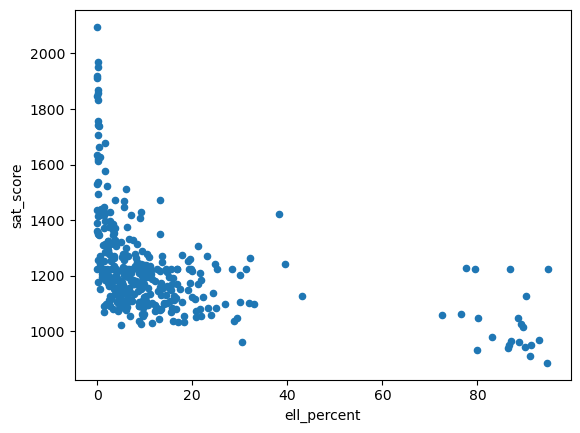

In [33]:
combined.plot(kind = 'scatter', x = 'ell_percent', y = 'sat_score')
plt.show()

По графику прослеживается отрицательная зависимость между показателем `ell_percent` и результатами SAT. Однако высокая плотность точек затрудняет интерпретацию взаимосвязи на уровне отдельных школ, поскольку многие наблюдения перекрываются. Агрегация данных по округам позволяет перейти от анализа отдельных школ к уровню округов и выявить различия в показателе `ell_percent` между ними:

In [34]:
combined['school_dist'] = combined['DBN'].str[:2]
combined['school_dist'].head()

0    01
1    01
2    01
3    01
4    01
Name: school_dist, dtype: object

-0.303111662607526


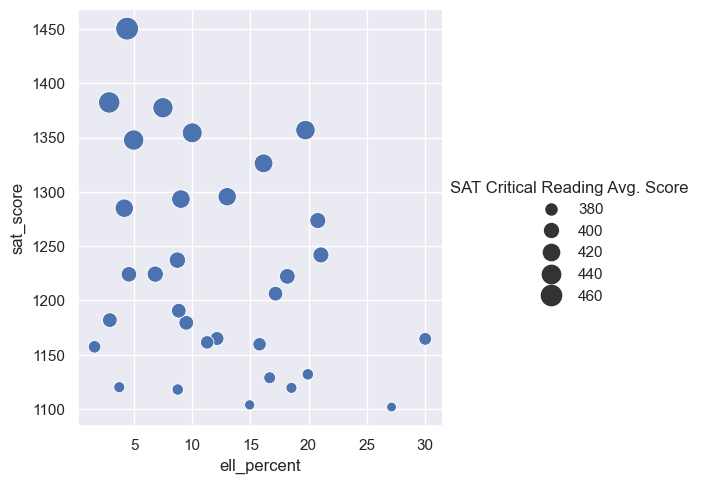

In [35]:
districts = combined.groupby('school_dist').mean(numeric_only = True)
districts.reset_index(inplace = True)

sns.set_theme()
sns.relplot(
    data = districts,
    x='ell_percent',
    y='sat_score',
    size='SAT Critical Reading Avg. Score',
    sizes=(50, 270)
)

print(districts['ell_percent'].corr(districts['sat_score']))
plt.show()

Полученные результаты подтверждают ранее выявленную тенденцию: в округах с большей долей учащихся, изучающих английский язык как второй (`ell_percent`), школы в среднем демонстрируют более низкие показатели как по общему баллу SAT, так и по разделу `Critical Reading`. Такая зависимость может отражать различия в условиях подготовки учащихся и указывать на потенциальные вопросы справедливости экзамена. Вместе с тем обнаруженная корреляция не свидетельствует о наличии причинно-следственной связи; для более точной оценки необходимо учитывать дополнительные социально-экономические и образовательные факторы.

---

Перейдём к анализу данных опросов учащихся, учителей и родителей. Целью данного этапа является выявление возможных связей между показателями восприятия школьной среды и итоговыми результатами SAT. Полученные результаты позволят оценить, в какой степени субъективные оценки участников образовательного процесса связаны с объективными экзаменационными показателями:

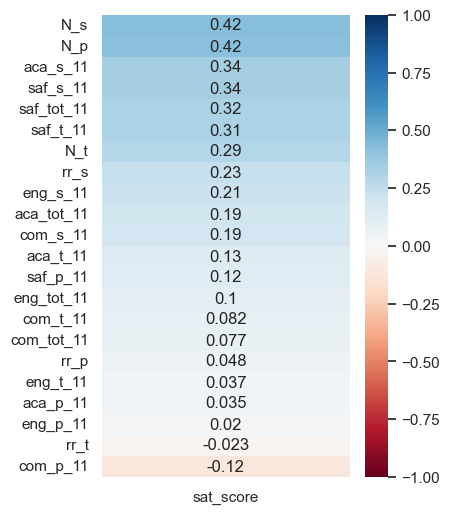

In [36]:
# Удаляем DBN из списка признаков, так как это уникальный идентификатор школы, который не отражает количественную характеристику для корреляционного анализа
survey_fields.remove("DBN")

correlations_survey = combined.corr(numeric_only=True).loc[survey_fields, ['sat_score']].sort_values('sat_score', ascending=False)

plt.figure(figsize = (4,6))
ax = sns.heatmap(correlations_survey, vmin=-1, vmax = 1, cmap = 'RdBu', annot = True)
plt.show()

Показатели `saf_t_11` и `saf_s_11`, отражающие восприятие безопасности в школе учителями и учащимися соответственно, имеют умеренную положительную корреляцию с результатами SAT (`0.31` и `0.34`). Это свидетельствует о том, что школы с более высокими оценками уровня безопасности также имеют более высокие баллы по экзаменам. Рассмотрим эту взаимосвязь подробнее:

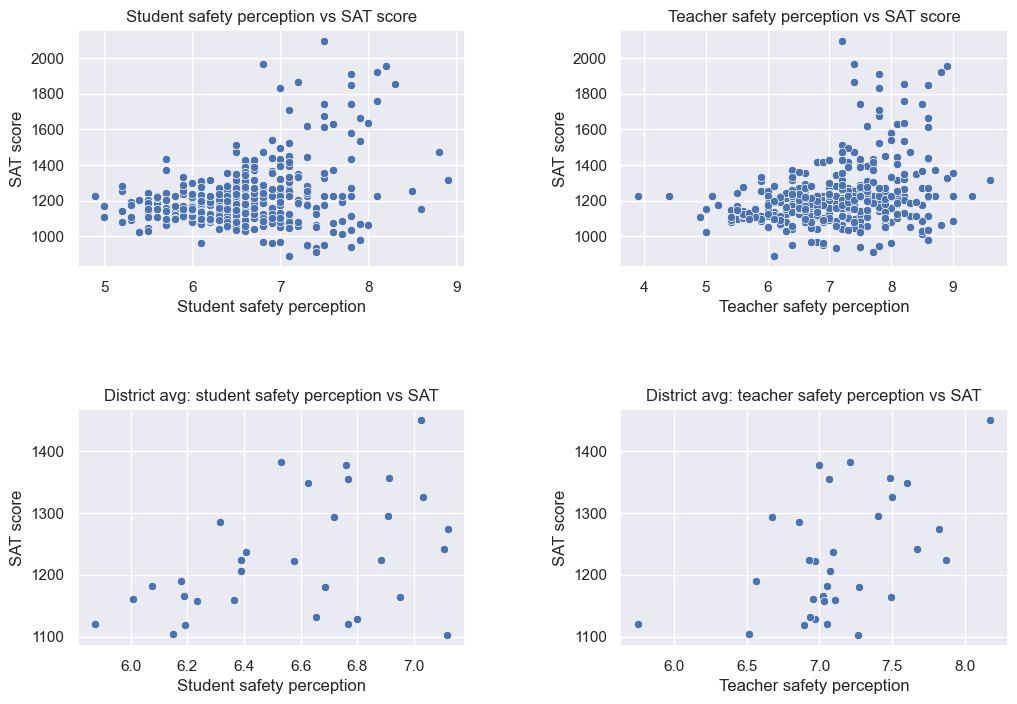

Schools: student safety perception vs SAT score (r): 0.338
Schools: teacher safety perception vs SAT score (r): 0.314

Districts: student safety perception vs SAT score (r): 0.428
Districts: teacher safety perception vs SAT score (r): 0.501


In [37]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.scatterplot(data=combined, x='saf_s_11', y='sat_score', ax=axes[0,0])
axes[0,0].set_title('Student safety perception vs SAT score')
axes[0,0].set_xlabel('Student safety perception')
axes[0,0].set_ylabel('SAT score')

sns.scatterplot(data=combined, x='saf_t_11', y='sat_score', ax=axes[0,1])
axes[0,1].set_title('Teacher safety perception vs SAT score')
axes[0,1].set_xlabel('Teacher safety perception')
axes[0,1].set_ylabel('SAT score')

sns.scatterplot(data=districts, x='saf_s_11', y='sat_score', ax=axes[1,0])
axes[1,0].set_title('District avg: student safety perception vs SAT')
axes[1,0].set_xlabel('Student safety perception')
axes[1,0].set_ylabel('SAT score')

sns.scatterplot(data=districts, x='saf_t_11', y='sat_score', ax=axes[1,1])
axes[1,1].set_title('District avg: teacher safety perception vs SAT')
axes[1,1].set_xlabel('Teacher safety perception')
axes[1,1].set_ylabel('SAT score')


fig.subplots_adjust(
    wspace=0.4,  # расстояние между столбцами
    hspace=0.6   # расстояние между строками
)

plt.show()

print(f"Schools: student safety perception vs SAT score (r): {combined['saf_s_11'].corr(combined['sat_score']):.3f}")
print(f"Schools: teacher safety perception vs SAT score (r): {combined['saf_t_11'].corr(combined['sat_score']):.3f}\n")

print(f"Districts: student safety perception vs SAT score (r): {districts['saf_s_11'].corr(districts['sat_score']):.3f}")
print(f"Districts: teacher safety perception vs SAT score (r): {districts['saf_t_11'].corr(districts['sat_score']):.3f}")

На всех четырёх графиках наблюдается умеренная положительная корреляция между показателями восприятия безопасности (со стороны учащихся и педагогов) и результатами SAT – как на уровне отдельных школ, так и на уровне округов. Более высокие оценки безопасности связаны с более высокими средними баллами экзамена.

Такая зависимость представляется логичной: ощущение безопасности способствует формированию благоприятной образовательной среды, в которой учащиеся могут эффективнее концентрироваться на учебном процессе.

---

После изучения показателей восприятия школьной среды перейдём к анализу демографических характеристик учащихся. Расовый состав школ – один из факторов, связанных с различиями в результатах SAT. При этом наблюдаемые различия в средних баллах могут быть связаны не столько с самим расовым составом учащихся, сколько с социально-экономическими условиями, в которых они получают образование. К ним относятся уровень финансирования школ, кадровая обеспеченность и доступ к подготовительным программам.

В исходных данных представлены доли учащихся по расовым и этническим категориям: `white_per`, `asian_per`, `black_per`, `hispanic_per`. Анализ корреляций между этими показателями и результатами SAT позволит оценить связь между демографическим составом школы и её средними экзаменационными баллами, а также выявить возможные вопросы равенства образовательных возможностей:

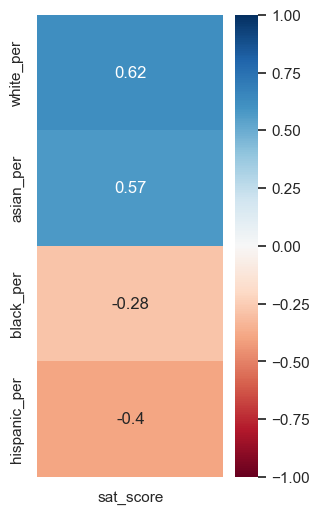

In [38]:
race_list = ['white_per', 'asian_per', 'black_per', 'hispanic_per']

correlations_race = combined.corr(numeric_only=True).loc[race_list, ['sat_score']].sort_values('sat_score', ascending=False)

plt.figure(figsize = (3,6))
ax = sns.heatmap(correlations_race, vmin=-1, vmax = 1, cmap = 'RdBu', annot = True)
plt.show()

Полученные коэффициенты корреляции свидетельствуют о наличии статистической связи между расовым составом учащихся и результатами SAT: 

- Доля белых учащихся демонстрирует положительную корреляцию с баллами экзамена (r = `0.62`), как и доля азиатских учащихся (r = `0.57`).
- В то же время для долей чернокожих (r = `-0.28`) и латиноамериканских (r = `-0.4`) учащихся наблюдается отрицательная корреляция.

Поскольку одной из ключевых целей исследования является оценка равенства образовательных возможностей, дальнейший анализ будет направлен на проверку устойчивости выявленных зависимостей на уровне округов, с особым вниманием к отрицательным линейным связям:

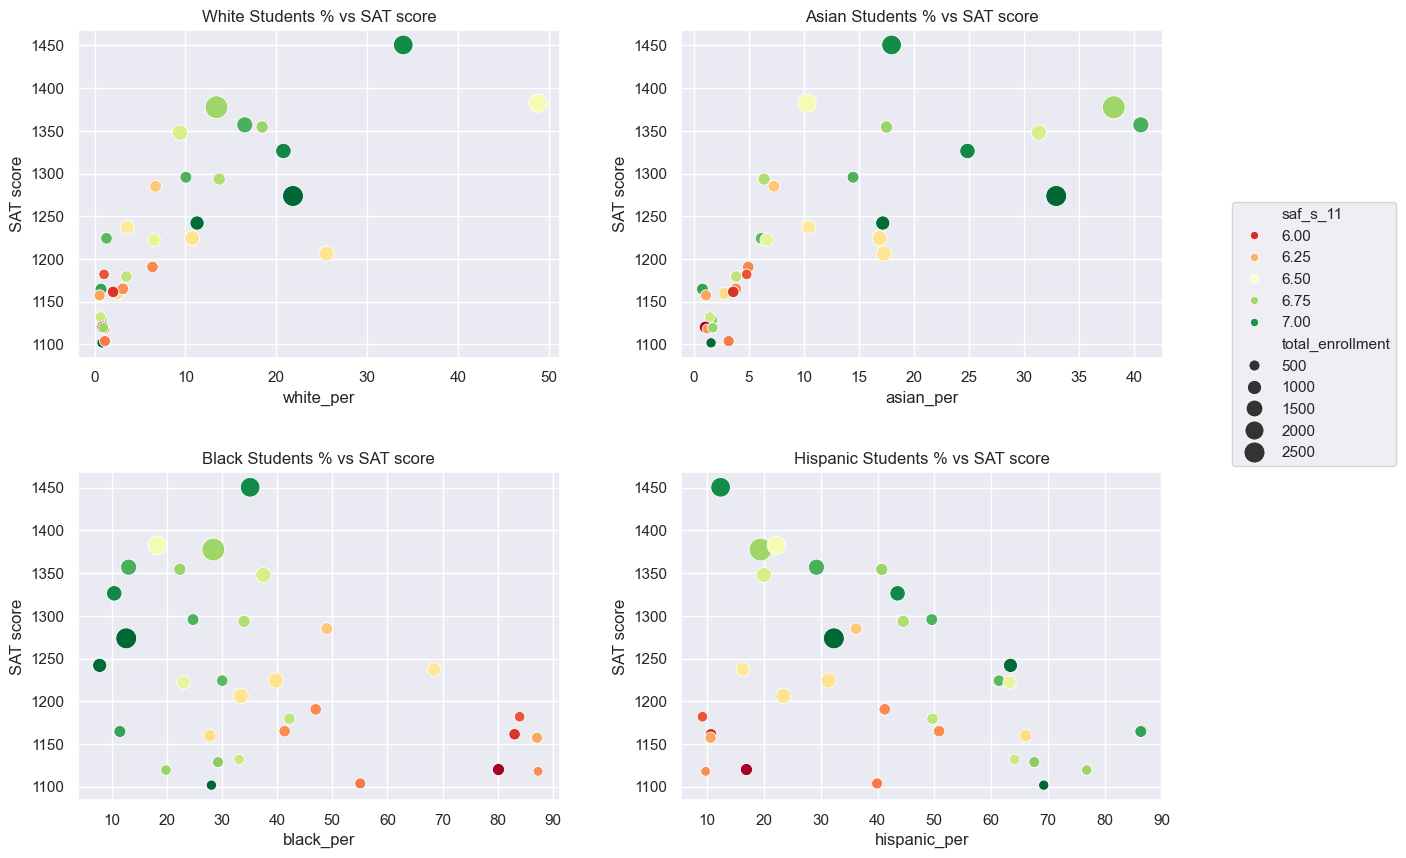

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, race in zip(axes, race_list):
    sns.scatterplot(
        data=districts,
        x=race,
        y='sat_score',
        size='total_enrollment',
        hue='saf_s_11',
        palette='RdYlGn',
        sizes=(50, 270),
        ax=ax
    )

    ax.set_title(f"{race.replace('_per', ' students %').title()} vs SAT score")
    ax.set_ylabel('SAT score')

# Оставляем легенду только у второго графика
for i in [0, 2, 3]:
    axes[i].get_legend().remove()

# Переносим легенду второго графика
legend = axes[1].get_legend()
legend.set_bbox_to_anchor((1.5, 0.5))

fig.subplots_adjust(
    wspace=0.25,  # расстояние между столбцами
    hspace=0.35   # расстояние между строками
)

plt.show()

На одном из графиков можно заметить интересную закономерность: среди округов, где доля чернокожих учащихся превышает `80%`, одновременно наблюдаются как более низкие средние баллы SAT, так и более низкие оценки восприятия безопасности. Поскольку таких округов всего пять, рассмотрим их более подробно:

In [40]:
districts[districts['black_per'] > 80]

,school_dist,SAT Critical Reading Avg. Score,SAT Math Avg. Score,SAT Writing Avg. Score,sat_score,AP Test Takers,Total Exams Taken,Number of Exams with scores 3 4 or 5,Total Cohort,CSD,...,grade_span_max,expgrade_span_max,zip,total_students,number_programs,priority08,priority09,priority10,lat,lon
15,16,371.529851,379.164179,369.415672,1120.109701,82.264423,126.519231,153.450000,247.185484,16.0,...,12.0,12.0,11219.000000,440.250000,1.750000,0.0,0.0,0.0,40.688008,-73.929686
16,17,386.571429,394.071429,380.785714,1161.428571,105.583791,163.087912,111.360714,121.357143,17.0,...,12.0,12.0,11220.642857,547.071429,1.642857,0.0,0.0,0.0,40.660313,-73.955636
17,18,373.454545,373.090909,371.454545,1118.000000,129.028846,197.038462,153.450000,72.771261,18.0,...,12.0,12.0,11224.000000,344.000000,1.090909,0.0,0.0,0.0,40.641863,-73.914726
22,23,380.666667,398.666667,378.000000,1157.333333,29.000000,31.000000,153.450000,87.000000,23.0,...,12.0,12.0,11219.000000,391.000000,1.333333,0.0,0.0,0.0,40.668586,-73.912298
28,29,395.764925,399.457090,386.707836,1181.929851,63.385817,96.514423,135.268750,98.108871,29.0,...,12.0,12.0,11413.625000,474.125000,1.250000,0.0,0.0,0.0,40.685276,-73.752740


Было установлено, что среди выделенных округов четыре (`16`, `17`, `18`, `23`) расположены в Бруклине, а пятый (`29`) – в Квинсе [см. источник](https://teachnyc.zendesk.com/hc/en-us/articles/360043956952-How-is-NYC-divided-into-school-districts). Указанные округа расположены в районах с исторически сложной социально‑экономической обстановкой. Такие условия могут оказывать влияние на образовательную среду и доступность ресурсов, что, в свою очередь, отражается на уровне академической вовлечённости учащихся и результатах экзамена SAT.

---

Продолжим анализ, рассмотрев связь между гендерным составом школ и результатами SAT. В данных представлены две характеристики, отражающие долю учащихся мужского и женского пола: `male_per` и `female_per`.

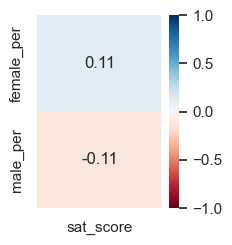

In [41]:
gender_list = ['male_per', 'female_per']

correlations_gender = combined.corr(numeric_only=True).loc[gender_list, ['sat_score']].sort_values('sat_score', ascending=False)

plt.figure(figsize = (2, 2.5))
ax = sns.heatmap(correlations_gender, vmin=-1, vmax = 1, cmap = 'RdBu', annot = True)
plt.show()

С учётом низких абсолютных значений коэффициентов корреляции (`|r| = 0.11`) выявленная связь является слабой, поэтому её дальнейшее детальное рассмотрение не представляется целесообразным.

---

Напоследок определим, какие школы можно считать наиболее привлекательными с точки зрения выбора места обучения ребёнка, если рассматривать покупку дома в Нью-Йорке. В первую очередь целесообразно обратить внимание на округа, в которых средние баллы SAT, а также общие показатели академических ожиданий учащихся являются наилучшими. Такой подход позволит выбирать сразу из нескольких сильных школ, расположенных в пределах одного округа, не привязываясь к какому-либо одному учебному заведению, что обеспечивает большую гибкость при выборе жилья:

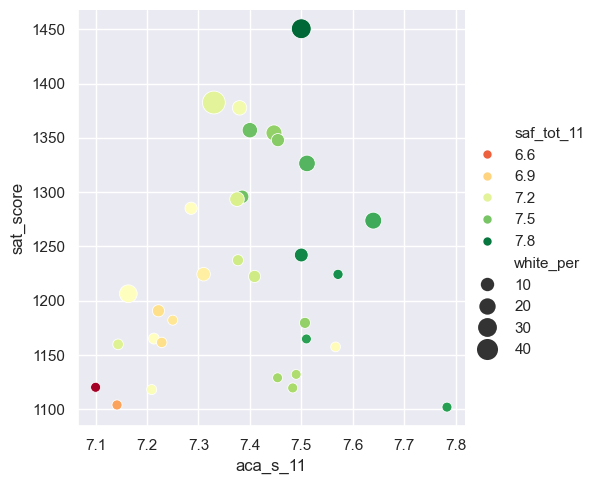

In [42]:
sns.relplot(
    data = districts,
    x='aca_s_11',
    y='sat_score',
    hue = 'saf_tot_11',
    palette = 'RdYlGn',
    size='white_per',
    sizes=(50, 270)
)

plt.show()

Исходя из поставленных критериев, можно выделить два округа, расположенных в верхней части графика (`обозначены наиболее крупными точками`). Оба округа характеризуются наиболее высокими средними баллами SAT, а также одними из лучших показателей, полученных по результатам следующих опросов:

- оценки академических ожиданий по ответам учащихся;
- общей оценки безопасности и уважительного отношения в школе (по мнению учителей, родителей и учащихся).
  
Кроме того, доля белых учащихся в данных округах составляет около 30-40%. Давайте узнаем, какие именно округа соответствует этим характеристикам:

In [43]:
districts[districts['sat_score'] > 1400]

,school_dist,SAT Critical Reading Avg. Score,SAT Math Avg. Score,SAT Writing Avg. Score,sat_score,AP Test Takers,Total Exams Taken,Number of Exams with scores 3 4 or 5,Total Cohort,CSD,...,grade_span_max,expgrade_span_max,zip,total_students,number_programs,priority08,priority09,priority10,lat,lon
21,22,473.5,502.75,474.25,1450.5,391.007212,614.509615,370.3625,580.25,22.0,...,12.0,12.0,11223.0,2149.0,2.25,0.0,0.0,0.0,40.618285,-73.952288


#### 1) 22-й школьный округ относится к Бруклину [см. источник](https://teachnyc.zendesk.com/hc/en-us/articles/360043956952-How-is-NYC-divided-into-school-districts). Изучим школы, входящие в его состав:

In [44]:
combined[combined['school_dist'] == '22']

,DBN,SCHOOL NAME,Num of SAT Test Takers,SAT Critical Reading Avg. Score,SAT Math Avg. Score,SAT Writing Avg. Score,sat_score,SchoolName,AP Test Takers,Total Exams Taken,...,priority05,priority06,priority07,priority08,priority09,priority10,Location 1,lat,lon,school_dist
276,22K405,MIDWOOD HIGH SCHOOL,824,478.0,519.0,476.0,1473.0,MIDWOOD HS,745.000000,1223.000000,...,0,0,0,0.0,0.0,0.0,"2839 Bedford Avenue\nBrooklyn, NY 11210\n(40.6...",40.633335,-73.952916,22
277,22K425,JAMES MADISON HIGH SCHOOL,518,436.0,475.0,439.0,1350.0,JAMES MADISON HS,323.000000,463.000000,...,0,0,0,0.0,0.0,0.0,"3787 Bedford Avenue\nBrooklyn, NY 11229\n(40.6...",40.609758,-73.948452,22
278,22K535,LEON M. GOLDSTEIN HIGH SCHOOL FOR THE SCIENCES,259,524.0,561.0,542.0,1627.0,LEON GOLDSTEIN HS SCIENCES,367.000000,575.000000,...,0,0,0,0.0,0.0,0.0,"1830 Shore Boulevard\nBrooklyn, NY 11235\n(40....",40.580847,-73.936089,22
279,22K555,BROOKLYN COLLEGE ACADEMY,131,456.0,456.0,440.0,1352.0,0,129.028846,197.038462,...,0,0,0,0.0,0.0,0.0,"350 Coney Island Avenue\nBrooklyn, NY 11218\n(...",40.649201,-73.971695,22


В состав округа входят всего четыре школы. Ознакомиться с ними более подробно можно по ссылке https://maps.app.goo.gl/x2EZQEqEckxXxaYp8. Видно, что три из них – `BROOKLYN COLLEGE ACADEMY`, `MIDWOOD HIGH SCHOOL`, а также `JAMES MADISON HIGH SCHOOL` расположены в относительной близости друг к другу. 

![Лучшие школы 22 округа Бруклина](best_schools_22_district.png)

Перейдём к рассмотрению следующего округа:

In [45]:
districts[(districts['sat_score'] > 1350) & (districts['aca_s_11'] < 7.35)]

,school_dist,SAT Critical Reading Avg. Score,SAT Math Avg. Score,SAT Writing Avg. Score,sat_score,AP Test Takers,Total Exams Taken,Number of Exams with scores 3 4 or 5,Total Cohort,CSD,...,grade_span_max,expgrade_span_max,zip,total_students,number_programs,priority08,priority09,priority10,lat,lon
30,31,457.5,472.5,452.5,1382.5,228.908654,355.111538,194.435,450.787097,31.0,...,12.0,12.0,10307.1,1847.5,5.0,0.0,0.0,0.0,40.59568,-74.125726


#### 2) 31-й округ расположен на Стейтен-Айленде. Выделим пять школ данного округа с наиболее высокими средними баллами SAT:

In [46]:
combined[combined['school_dist'] == '31'].sort_values('sat_score', ascending = False).head()

,DBN,SCHOOL NAME,Num of SAT Test Takers,SAT Critical Reading Avg. Score,SAT Math Avg. Score,SAT Writing Avg. Score,sat_score,SchoolName,AP Test Takers,Total Exams Taken,...,priority05,priority06,priority07,priority08,priority09,priority10,Location 1,lat,lon,school_dist
356,31R605,STATEN ISLAND TECHNICAL HIGH SCHOOL,227,635.0,682.0,636.0,1953.0,STATEN ISLAND TECHNICAL HS,528.000000,905.000000,...,0,0,0,0.0,0.0,0.0,"485 Clawson Street\nStaten Island, NY 10306\n(...",40.567913,-74.115362,31
349,31R080,THE MICHAEL J. PETRIDES SCHOOL,107,472.0,488.0,466.0,1426.0,PS 080 MICHAEL J. PETRIDES,162.000000,243.000000,...,0,0,0,0.0,0.0,0.0,"715 Ocean Terrace\nStaten Island, NY 10301\n(4...",40.607453,-74.101482,31
353,31R455,TOTTENVILLE HIGH SCHOOL,807,462.0,486.0,470.0,1418.0,TOTTENVILLE HS,396.000000,687.000000,...,0,0,0,0.0,0.0,0.0,"100 Luten Avenue\nStaten Island, NY 10312\n(40...",40.528229,-74.192154,31
354,31R460,SUSAN E. WAGNER HIGH SCHOOL,535,455.0,474.0,459.0,1388.0,SUSAN E. WAGNER HS,279.000000,408.000000,...,0,0,0,0.0,0.0,0.0,"1200 Manor Road\nStaten Island, NY 10314\n(40....",40.598652,-74.123105,31
347,31R047,CSI HIGH SCHOOL FOR INTERNATIONAL STUDIES,137,452.0,451.0,450.0,1353.0,0,129.028846,197.038462,...,0,0,0,0.0,0.0,0.0,"100 Essex Drive\nStaten Island, NY 10314\n(40....",40.582022,-74.157848,31


Четыре из пяти школ – `THE MICHAEL J. PETRIDES SCHOOL`, `SUSAN E. WAGNER HIGH SCHOOL`, `CSI HIGH SCHOOL FOR INTERNATIONAL STUDIES` и `STATEN ISLAND TECHNICAL HIGH SCHOOL` – расположены в непосредственной близости друг от друга https://maps.app.goo.gl/LcufcLYVLf9uc5rz6. Кроме того, два рассматриваемых нами округа являются соседними и соединены мостом Верразано-Нарроус.


![Лучшие школы 31 округа Стейтен-Айленда](best_schools_31_district.png)

Таким образом, выбор жилья в данной зоне открывает доступ к девяти сильным образовательным учреждениям в пределах двух округов, что расширяет возможности для получения ребёнком качественного образования в благоприятной школьной среде.